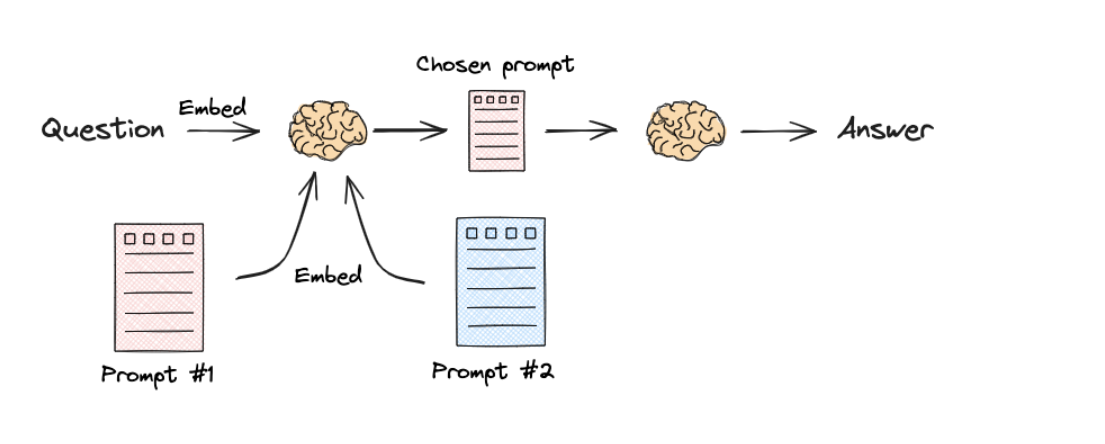

In [2]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.utils.math import cosine_similarity
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")

In [3]:

# 2. Define our Departmental Routes (The "Anchors")
# We use simple phrases to 'anchor' the vector space for each route
routes = {
    "physics": "What is the speed of light? Tell me about gravity and black holes.",
    "math": "Solve for x. How do I calculate the derivative of a function?",
}

# 3. Pre-embed the route anchors (Do this once at the start)
route_names = list(routes.keys())
route_embeddings = embeddings.embed_documents(list(routes.values()))
route_names, route_embeddings

(['physics', 'math'],
 [[-0.002982029,
   0.007587047,
   0.009249023,
   -0.022741102,
   0.004712791,
   -0.0091341715,
   -0.016368816,
   -0.0144625725,
   0.024597595,
   -0.06533155,
   -0.028037889,
   0.023989093,
   -0.02459196,
   -0.02616549,
   0.024136381,
   0.0011929815,
   -0.00036253151,
   -0.0002447138,
   -0.0075095175,
   0.0009536674,
   0.02586026,
   -0.008308171,
   -0.023236059,
   0.017336125,
   -0.017366875,
   0.011929519,
   -0.013392489,
   -0.012476704,
   -0.0021166108,
   0.105079316,
   0.0031893908,
   -0.023485683,
   0.013909792,
   0.010599396,
   0.013321798,
   -0.007626935,
   -0.010351126,
   0.004165615,
   0.008867679,
   0.0008223307,
   0.004089095,
   0.008974094,
   0.012461647,
   -0.009859908,
   0.0030100343,
   -0.013643399,
   -0.007812796,
   -0.01366539,
   0.007079424,
   0.02792528,
   0.0145261455,
   0.010345498,
   -0.007494428,
   -0.024206907,
   0.023250034,
   0.014528358,
   -0.008899186,
   -0.0038089545,
   0.00573687

In [4]:
def semantic_router(input_data):
    query = input_data["query"]
    
    # Embed the incoming user query
    query_embedding = embeddings.embed_query(query)
    
    # Calculate similarity between query and our two anchors
    similarities = cosine_similarity([query_embedding], route_embeddings)[0]
    
    # Pick the index of the highest similarity score
    best_match_idx = similarities.argmax()
    chosen_route = route_names[best_match_idx]
    
    print(f"--- [DEBUG] Semantic Router chose: {chosen_route.upper()} ---")
    
    # Return the specific prompt template based on the math
    if chosen_route == "physics":
        return PromptTemplate.from_template("You are a Physics Professor: {query}")
    else:
        return PromptTemplate.from_template("You are a Math Whiz: {query}")

In [5]:
chain = (
    {"query": RunnablePassthrough()}
    | RunnableLambda(semantic_router)
    | llm
    | StrOutputParser()
)

chain.invoke("Why is the sky blue?")

--- [DEBUG] Semantic Router chose: PHYSICS ---


'Ah, a classic! And a beautiful one, too. It\'s one of those everyday wonders that perfectly illustrates some fundamental principles of light and matter. Let\'s break it down, shall we?\n\nThe short answer is **Rayleigh Scattering**. But to truly understand it, we need to unpack a few concepts.\n\n### 1. What is Sunlight?\n\nFirst, remember that the light from our Sun, which appears "white" to us, is actually a mixture of all the colors of the rainbow – a spectrum of electromagnetic radiation. Each color corresponds to a different **wavelength** of light.\n*   **Violet and Blue light** have shorter wavelengths.\n*   **Red and Orange light** have longer wavelengths.\n\n### 2. What is Earth\'s Atmosphere Made Of?\n\nOur atmosphere is primarily composed of tiny gas molecules, mainly nitrogen (N₂) and oxygen (O₂). These molecules are incredibly small – much, much smaller than the wavelengths of visible light. There are also some dust particles and water vapor, but it\'s the gas molecules t